# Assigment 7: Logistic Regression 
##### Author: Md Ashhar Farooqui
##### Date: 18-07-2025

# Load important libraries

In [2]:
# 1. Load libraries and data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Exploratory Data Analysis (EDA)
a. Load the dataset and perform exploratory data analysis (EDA)

In [3]:
train = pd.read_csv('Titanic_train.csv')
test = pd.read_csv('Titanic_test.csv')

b. Examine the features, their types, and summary statistics.

In [4]:
print(train.info())
print(train.describe(include='all'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
        PassengerId    Survived      Pclass                 Name   Sex  \
count    891.000000  891.000000  891.000000                  891   891   
unique          NaN         NaN         NaN                  891     2   
top             N

c. Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.

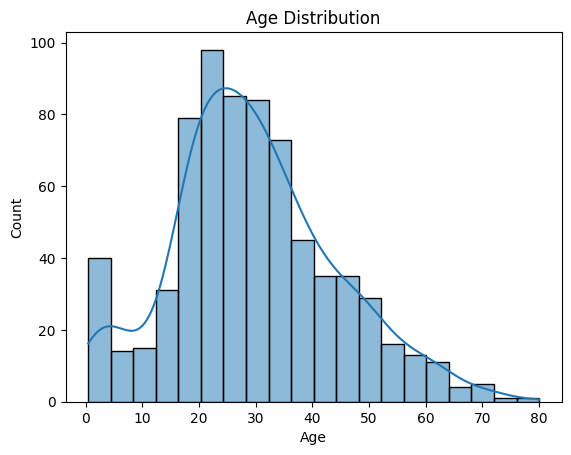

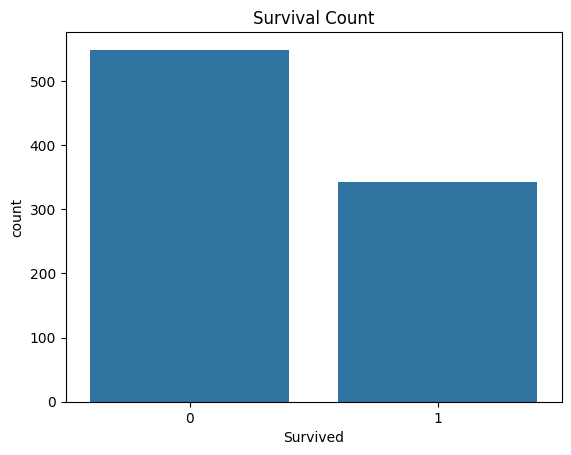

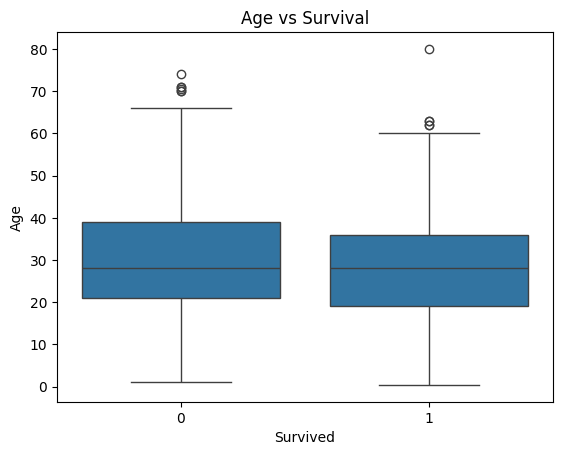

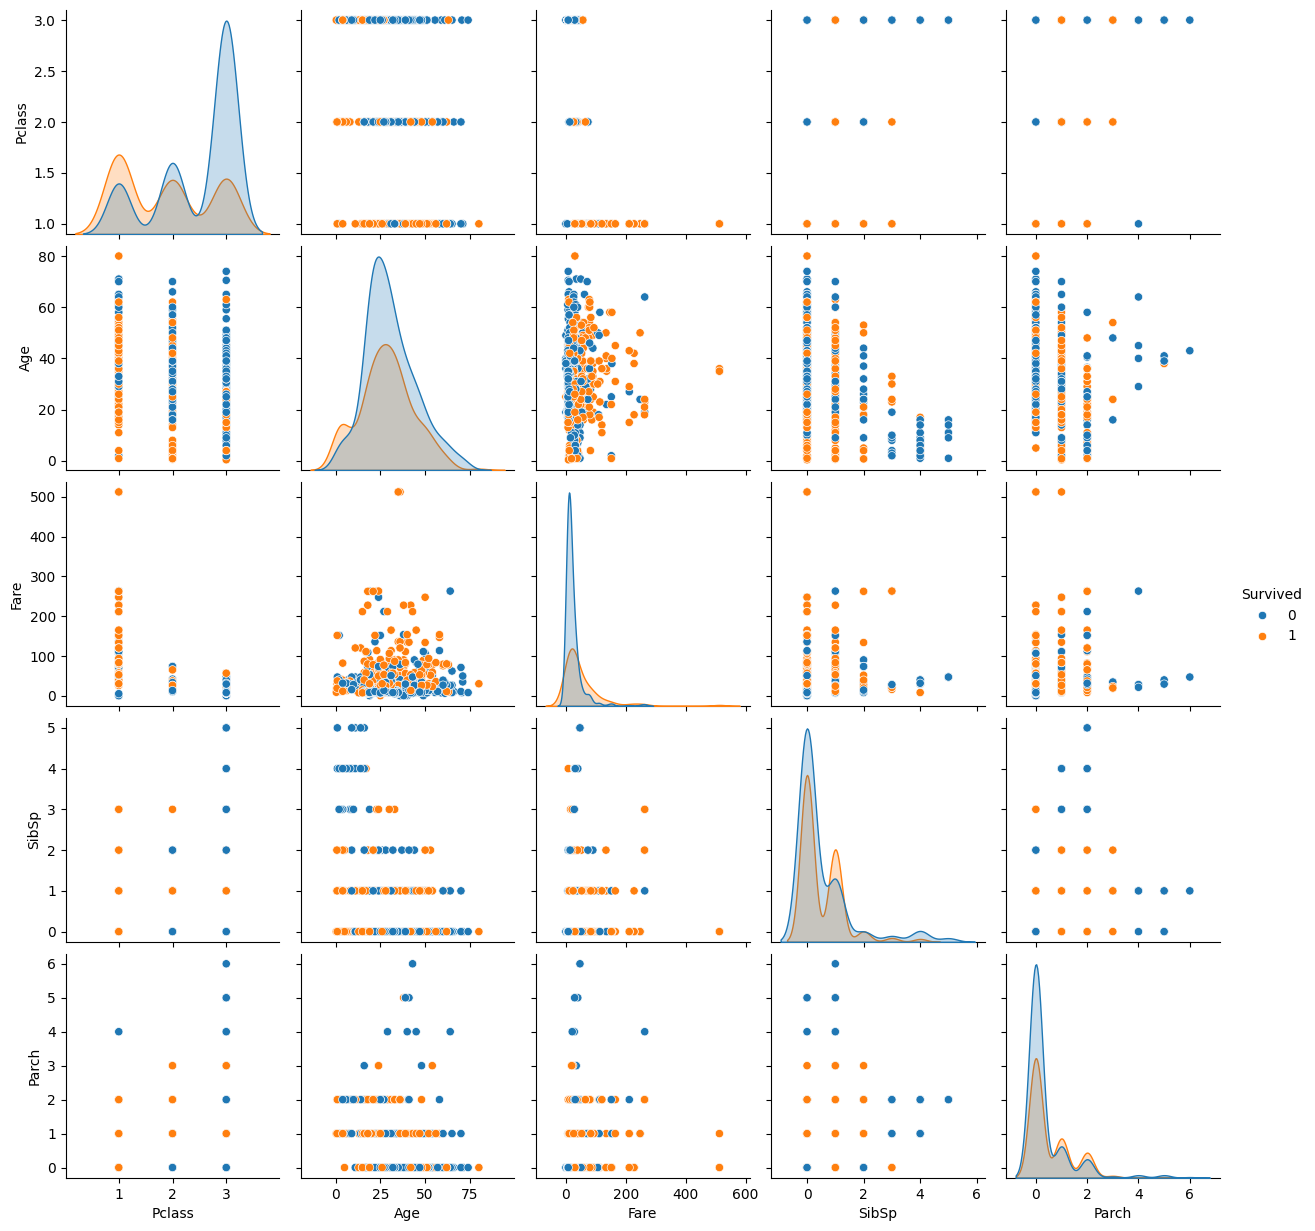

In [5]:
# 3. Visualizations
sns.histplot(train['Age'].dropna(), kde=True)
plt.title('Age Distribution')
plt.show()

sns.countplot(x='Survived', data=train)
plt.title('Survival Count')
plt.show()

sns.boxplot(x='Survived', y='Age', data=train)
plt.title('Age vs Survival')
plt.show()

sns.pairplot(train[['Survived', 'Pclass', 'Age', 'Fare', 'SibSp', 'Parch']].dropna(), hue='Survived')
plt.show()

Analyze any patterns or correlations observed in the data.

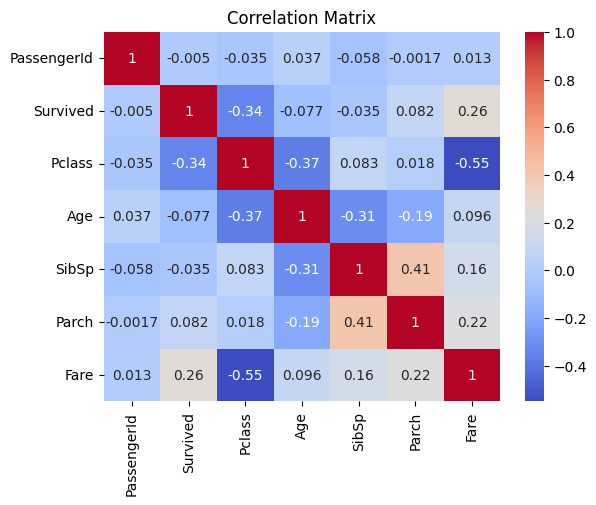

In [6]:
# Correlation heatmap
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# 2. Data Preprocessing:
a. Handle missing values (e.g., imputation).

In [7]:
# Handle missing values
train['Age'].fillna(train['Age'].median(), inplace=True)
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)
train['Fare'].fillna(train['Fare'].median(), inplace=True)
test['Age'].fillna(test['Age'].median(), inplace=True)
test['Fare'].fillna(test['Fare'].median(), inplace=True)
test['Embarked'].fillna(test['Embarked'].mode()[0], inplace=True)

C:\Users\Ashhar\AppData\Local\Temp\ipykernel_12128\346326561.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].median(), inplace=True)
C:\Users\Ashhar\AppData\Local\Temp\ipykernel_12128\346326561.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


b. Encode categorical variables.

In [8]:
# Encode categorical variables
from sklearn.preprocessing import LabelEncoder

for col in ['Sex', 'Embarked']:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

# Drop irrelevant columns
X_train = train.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Survived'], axis=1)
y_train = train['Survived']
X_test = test.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

# 3. Model Building:
a. Build a logistic regression model using appropriate libraries (e.g., scikit-learn).

b. Train the model using the training data.

In [9]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# 4. Model Evaluation:
a. Evaluate the performance of the model on the testing data using accuracy, precision, recall, F1-score, and ROC-AUC score.

Visualize the ROC curve.


Accuracy: 0.8002244668911336
Precision: 0.7611464968152867
Recall: 0.6988304093567251
F1 Score: 0.7286585365853658
ROC-AUC: 0.8570420434815029


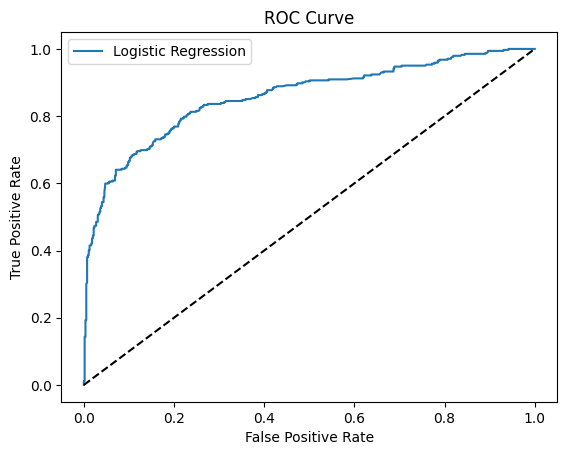

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Predict on train (or use cross-validation)
y_pred = model.predict(X_train)
y_prob = model.predict_proba(X_train)[:, 1]

print('Accuracy:', accuracy_score(y_train, y_pred))
print('Precision:', precision_score(y_train, y_pred))
print('Recall:', recall_score(y_train, y_pred))
print('F1 Score:', f1_score(y_train, y_pred))
print('ROC-AUC:', roc_auc_score(y_train, y_prob))

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_train, y_prob)
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 5. Interpretation:
a. Interpret the coefficients of the logistic regression model.

b. Discuss the significance of features in predicting the target variable (survival probability in this case).


In [11]:
# Coefficient interpretation
coefficients = pd.Series(model.coef_[0], index=X_train.columns)
print(coefficients.sort_values(ascending=False))

# Discuss: Positive coefficients increase survival odds, negative decrease.

Fare        0.002159
Age        -0.038025
Parch      -0.084810
Embarked   -0.213879
SibSp      -0.316211
Pclass     -1.050664
Sex        -2.631109
dtype: float64


# 6. Deployment with Streamlit:
In this task, you will deploy your logistic regression model using Streamlit. The deployment can be done locally or online via Streamlit Share. Your task includes creating a Streamlit app in Python that involves loading your trained model and setting up user inputs for predictions. 


Save your trained model with pickle:

In [15]:
# Save your trained model with pickle:
import pickle
with open('logreg_model.pkl', 'wb') as f:
    pickle.dump(model, f)

<img src='Streamlit Output.png'>

<img src='Streamlit Not Survived .png'>